# Creating a multi-agent chatbot with routing and orchestration

In [1]:
"""Real routing-and-orchestration lab for a LangGraph lecture.

This lab routes a question to one or more real specialist nodes:
    - Weather specialist: OpenWeatherMap
    - Web specialist: Tavily, with DuckDuckGo as a fallback
    - Paper specialist: LangChain ArxivLoader downloads paper PDFs and extracts text

The synthesizer combines every selected specialist result into one answer.

Install:
    pip install -U langchain langgraph langchain-groq \
        langchain-tavily langchain-community arxiv pymupdf requests python-dotenv

Required .env values:
    GROQ_API_KEY=...
    TAVILY_API_KEY=...
    OPENWEATHER_API_KEY=...
"""

import json
import os
import warnings


import requests
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_community.tools import DuckDuckGoSearchRun

from langchain_tavily import TavilySearch
from langchain.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph

from pydantic import BaseModel, Field #for structured output 
from typing import Literal, TypedDict #for langgraph state

from langchain_community.document_loaders import ArxivLoader

from langchain.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage


load_dotenv()
warnings.filterwarnings("ignore", category=DeprecationWarning)

WEATHER_API_KEY = os.getenv("OPENWEATHER_API_KEY")

# The primary model makes routing and final synthesis decisions.
llm_primary = init_chat_model(
    model="gpt-5.4-nano", model_provider="openai"
)


/Users/nali/Documents/YTLLMs/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/l9/f7m3nyf55s1947yhx1spp9fw0000gp/T/ipykernel_2559/1485417592.py:28: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


# Create ResearchState as graphState 

In [2]:
class ResearchState(TypedDict):
    question:str 

    routes:list[str]

    weather_result:str
    web_result:str
    paper_result:str

    final_answer:str

# Create weather node/agent/worker  

## getWeather tool

In [3]:
@tool
def getWeather(location:str)->str:
    """Return the weather information based on the given location and or zipcode"""
    url = "https://api.openweathermap.org/data/2.5/weather?"

    params={
        "q":location,
        "appid":WEATHER_API_KEY,
        "units":"imperial"
    }

    try:
        response = requests.get(url,params=params,timeout=10)
        return response.json()
    except:
        return f"The requested weather information is not available"

## create structured output for getWeather tool

In [4]:
class WeatherRequest(BaseModel):
    location:str = Field(description="The city to look up")

weather_location_llm = llm_primary.with_structured_output(WeatherRequest)

In [5]:
weather_location_llm.invoke("weather in Cincinati")

WeatherRequest(location='Cincinati')

### create the weather node

In [6]:
def run_weather_specialist(state:ResearchState)->ResearchState: 
    """Extract location and then return weather information"""

    request = weather_location_llm.invoke([
        SystemMessage(content="extract location from the query"),
        HumanMessage(content=f"{state["question"]}")
    ]
    )

    response = getWeather.invoke({"location":request.location})

    return {"weather_result":response}

### test the weather node 

In [7]:
initial_state = {
    "question":"weather in Peoria"
}
#run_weather_specialist(initial_state)

# Create web_search node 

In [8]:
# Search tool using Tavily 
from langchain_tavily import TavilySearch

web_search = TavilySearch(
    max_results=3, 
    topic="general",
    search_depth="basic"
)


# Create duckduckgosearch 

from langchain_community.tools import DuckDuckGoSearchRun 

ddg_search = DuckDuckGoSearchRun()

## Create run_web_special node/agent 

In [9]:
def run_web_specialist(state:ResearchState)->ResearchState: 
    """return web search result"""
    try:
        result = web_search.invoke({"query":state["question"]})
        return {"web_result":json.dumps(result)}
    except Exception:
        result = ddg_search.invoke({"query":state["question"]})
        return {"web_result":json.dumps(result)}

In [10]:
# test the web_search node 
initial_state = {
    "question":"Top news today is USA"
}
run_web_specialist(initial_state)

{'web_result': '{"query": "Top news today is USA", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.reuters.com/world/us", "title": "Latest U.S. News | Top headlines from the USA", "content": "14 hours agoEx-husband of Massachusetts woman testifies about discovering she killed their 3 children Image 8: Lindsay Clancy murder trial at Plymouth Superior Court, in Plymouth \\n   16 hours agoUS lawmakers press Health Secretary Robert F. Kennedy Jr. on vaccine settlement [...] Legal category\\u00b722 hours ago Prosecutors say Charlie Kirk was attacked for his politics, cite anti-LGBT views \\nTyler Robinson, the man accused of killing Charlie Kirk, targeted the right-wing \\u200cactivist for his political views, prosecutors said on Tuesday, citing Kirk\'s opposition to gay marriage and transgender rights. [...] Image 9: Memorial service for slain conservative commentator Charlie Kirk, in Glendale\\n   United States category\\u00b721 hours ago Israel

# Create research_paper node/agent

## Create load_argix_paper tool

In [11]:
import arxiv
arxiv.Client.query_url_format = "https://export.arxiv.org/api/query?{}"
#client = arxiv.Client()
@tool
def load_arxiv_papers(query:str, max_results:int=2): 
    """Download research paper from arxiv"""

    try:
        loader = ArxivLoader(
            query=query,
            load_max_docs=max_results,
            load_all_available_meta= True,
            doc_content_chars_max=12000
        )

        documents = loader.load()

        papers = [{
                "title":document.metadata.get("Title","unknown title"),
                "authors":document.metadata.get("Authors","unknown authors"),
                "content":document.page_content
        }
        for document in documents
        ]

        return json.dumps(papers)
    except Exception as error:
        return f"Error in loading papers. {error}"

In [12]:
#response = load_arxiv_papers.invoke({"query":"AI and ML", "max_results":2})

#print(response)

## Create run_paper_specialist 

In [13]:
def run_paper_specialist(state:ResearchState)->ResearchState:
    """Resturn arxiv paper and summerzie the context"""
    papers = load_arxiv_papers.invoke({"query":state["question"],"max_results":2})

    summary = llm_primary.invoke(
        [
            SystemMessage(content="""Summerize the research paper based on the user question"""),
            HumanMessage(content=f"user Question: {state["question"]}, \n Papers: {papers}")
        ]
    )

    return {"paper_results":summary}

# Create router node

In [14]:
class RouteDecision(BaseModel): 
    routes: list[Literal["weather","web","paper"]] = Field(
        description="""Return the routes based on the question. Return weather for weather related query.
        return web for internet search or current affiars related query, return paper for arxiv papers and 
        other papers related query.
        """
    )

router_llm = llm_primary.with_structured_output(RouteDecision)

In [15]:
router_llm.invoke("Top news in USA")

RouteDecision(routes=['web'])

In [16]:
def router(state:ResearchState)->ResearchState:

    decision = router_llm.invoke([
        SystemMessage(content="Return routes based on the user query"),
        HumanMessage(content=f"Question:{state["question"]}")
    ])

    return {"routes":decision.routes}

## Selection the conditional routes function

In [17]:
def select_specialists(state:ResearchState)->list[str]:
    """Select the route or list of routes"""
    destinations = [] 

    if("weather" in state["routes"]):
        destinations.append("weather_specialist")
    if("web" in state["routes"]):
        destinations.append("web_specialist")
    if("paper" in state["routes"]):
        destinations.append("paper_specialist")

    return destinations


# Create Synthesizer node 

In [18]:
def synthesizer(state:ResearchState)->ResearchState:
    """combine the results based on the specialist nodes output"""

    evidence = [] 
    if(state.get("weather_result")):
        evidence.append(f" Weather specialist: {state["weather_result"]}")
    if(state.get("web_result")):
        evidence.append(f" Web specialist: {state["web_result"]}")
    if(state.get("paper_result")):
        evidence.append(f" Paper specialist: {state["paper_result"]}")


    response = llm_primary.invoke([
        SystemMessage(content="""You are a nice synthesizer. Your job is to combine the specialists' input as a final 
        answer to the user based on the user query.
        """),
        HumanMessage(content=f"User questions: {state["question"]} \n Specialists' input: {evidence}")
    ])


    return {"final_answer":response}

# Complete the graph 

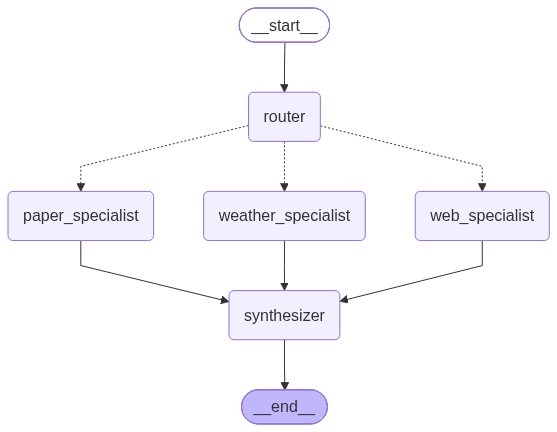

In [19]:
graph = StateGraph(ResearchState)

#Nodes
graph.add_node(router)
graph.add_node("weather_specialist",run_weather_specialist)
graph.add_node("web_specialist",run_web_specialist)
graph.add_node("paper_specialist",run_paper_specialist)
graph.add_node(synthesizer)

#Edges 
graph.add_edge(START,"router")
graph.add_conditional_edges(
    "router", select_specialists, ["weather_specialist","web_specialist","paper_specialist"]
)
graph.add_edge("weather_specialist","synthesizer")
graph.add_edge("web_specialist","synthesizer")
graph.add_edge("paper_specialist","synthesizer")

graph.add_edge("synthesizer", END)

graph = graph.compile(checkpointer=InMemorySaver())
graph

## test the graph 

In [20]:
confifure = {"configurable":{"thread_id":1}}

In [25]:
initial_state = {
    "question":"Top news in USA. Weather in Peoria city. Describe Transformer Architecture." 
}

In [26]:
try: 
    response = graph.invoke(initial_state,confifure) 
    #print(response["final_answer"].content)
except Exception as e: 
    print("error in generating final asnwer. {e}")


In [27]:
print(response["final_answer"].content)

## Top news in USA
I don’t have reliable USA top-news headlines from the provided sources (the web specialist results didn’t return any current national news list—only an unrelated local weather/search result and a Chicago morning news video).

If you tell me your preferred category (politics, economy, tech, sports) and whether you want “breaking” vs “today’s top,” I can format a clean top-news briefing accordingly.

---

## Weather in Peoria (Peoria, Illinois)
- **Conditions:** Overcast clouds  
- **Temperature:** ~**71.7°F** (≈ **71.4°F** reported)  
- **Feels like:** **~73°F**  
- **High / Low:** **~73.1°F / 70.5°F**  
- **Humidity:** **~87–95%**  
- **Wind:** **~13.7–14.8 mph** from the **S–SSE** (gusts up to **~19–25 mph**)  
- **Cloud cover:** **100%**  
- **Visibility:** **~10 km**  
- **Rain chance:** **~29%** (patchy rain nearby)

---

## Transformer Architecture (description)
A **Transformer** is a neural network architecture designed to handle sequences (like text) using **a

In [28]:
print(response)

{'question': 'Top news in USA. Weather in Peoria city. Describe Transformer Architecture.', 'routes': ['web', 'weather', 'paper'], 'weather_result': {'coord': {'lon': -89.7668, 'lat': 40.7667}, 'weather': [{'id': 804, 'main': 'Clouds', 'description': 'overcast clouds', 'icon': '04d'}], 'base': 'stations', 'main': {'temp': 71.67, 'feels_like': 73, 'temp_min': 70.52, 'temp_max': 73.11, 'pressure': 1009, 'humidity': 95, 'sea_level': 1009, 'grnd_level': 985}, 'visibility': 10000, 'wind': {'speed': 13.67, 'deg': 162, 'gust': 25.19}, 'clouds': {'all': 100}, 'dt': 1785530750, 'sys': {'type': 2, 'id': 2112213, 'country': 'US', 'sunrise': 1785495275, 'sunset': 1785546970}, 'timezone': -18000, 'id': 4905697, 'name': 'Peoria', 'cod': 200}, 'web_result': '{"query": "Top news in USA. Weather in Peoria city. Describe Transformer Architecture.", "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "Weather in Peoria, Illinois, USA", "url": "https://www.weatherapi.com/", "c